# Network Monitor ANN — Intrusion Detection Model Training

## Purpose
This notebook builds, trains, and evaluates a multi-class Artificial Neural Network (ANN)
for network intrusion detection. The model classifies network traffic flows into one of
seven categories: BENIGN, DDoS, DoS, Brute Force, Port Scan, Web Attack, and Bot.

## Inputs
- `Pruned_Data.csv` — the 19-feature, labeled dataset produced by `SM_feature_selection.ipynb`

## Outputs
- `Inspector_Gadget.keras` — full-precision Keras model for evaluation and archival
- `Inspector_Gadget_quant.tflite` — integer-quantized TensorFlow Lite model for edge
  deployment on a Raspberry Pi
- `NMMscaler.joblib` — fitted StandardScaler for use during inference

## Model Name
The model is named `Inspector_Gadget`.

## Deployment Target
The trained model is designed for real-time inference on a Raspberry Pi using the
TensorFlow Lite runtime. The quantized `.tflite` model reduces memory and compute
requirements for this resource-constrained environment.

In [ ]:
# imports for building and training our ANN
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input, Activation
from tensorflow.keras.optimizers import Adam
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

2026-03-26 07:33:56.295075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774524836.388812    9020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774524836.417439    9020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774524836.644958    9020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774524836.644979    9020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774524836.644980    9020 computation_placer.cc:177] computation placer alr

# Network and Training Parameters

The following hyperparameters govern model architecture and training:

| Parameter | Value | Rationale |
|---|---|---|
| `FEATURES` | 19 | Number of input features from `Pruned_Data.csv` |
| `CLASSES` | 7 | Number of attack categories (BENIGN + 6 attack types) |
| `EPOCHS` | 50 | Upper-bound — EarlyStopping will terminate training early if validation loss plateaus (see Compiling and Training section) |
| `BATCH_SIZE` | 256 | Balances gradient stability and training speed; larger batches generalize well for structured tabular data ([Ultralytics](https://www.ultralytics.com/glossary/batch-size), 2026) |
| `LEARNING_RATE` | 0.001 | Adam optimizer default; empirically stable for deep classification networks (Géron, 2019) |
| `DROPOUT` | 0.3 | 30% of neurons randomly zeroed per forward pass to prevent overfitting on the majority class (Géron, 2019; Gulli & Pal, 2017) |
| `OPTIMIZER` | Adam | Adaptive learning rate optimizer; standard choice for multi-class classification (Géron, 2019; Gulli & Pal, 2017) |

**Architecture layer sizes:**
- Layer 1: 250 neurons
- Layer 2: 100 neurons
- Layer 3: 50 neurons
- Output: 7 neurons with softmax (one probability per class)

In [2]:
FEATURES = 19
CLASSES = 7
EPOCHS = 50
BATCH_SIZE = 256 
LEARNING_RATE = 0.001
DROPOUT = 0.3
VERBOSE = 1 
OPTIMIZER = Adam()

FIRST_LAYER = 250
SECOND_LAYER = 100
THIRD_LAYER = 50

I0000 00:00:1774524840.627188    9020 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


# Importing the Pruned Dataset

The 19-feature dataset produced by `SM_feature_selection.ipynb` is loaded here. The class
distribution output below reveals significant imbalance — a key challenge for training an
unbiased multi-class classifier that must be addressed before model training.

In [3]:
# import data and check labels
data = pd.read_csv('Pruned_Data.csv')
print(data.shape)
print(data['Attack Type'].value_counts())

(2522362, 20)
Attack Type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


# Data Preprocessing

## Removing Extreme Minority Classes

The class distribution reveals two attack types with critically low sample counts:
- **Heartbleed:** 11 records (~0.0004% of dataset)
- **Infiltration:** 36 records (~0.0013% of dataset)

These counts are too small for SMOTE to generate meaningful synthetic samples. SMOTE
requires at least `k_neighbors` real samples to interpolate between. With only 11 records,
all synthetic samples would be nearly identical, providing no generalizable signal. This is
an inherent limitation of the CICIDS-2017 dataset — both attack types occurred rarely
during the capture period.

These two classes are removed. The model is trained on the remaining **6 attack categories
plus BENIGN** (7 classes total) (Pervez, 2023).

In [17]:
data = data[-data['Attack Type'].isin(['Heartbleed', 'Infiltration'])]
# check label counts again
print(data.shape)
print(data['Attack Type'].value_counts())

(2522315, 20)
Attack Type
BENIGN         2096484
DoS             193748
DDoS            128016
Port Scan        90819
Brute Force       9152
Web Attack        2143
Bot               1953
Name: count, dtype: int64


## Class Imbalance Mitigation Strategy

The raw dataset is heavily imbalanced: BENIGN traffic represents approximately 83% of all
records. A model trained on this distribution without correction would learn to classify
nearly everything as BENIGN, achieving high raw accuracy while failing to detect attacks.

**Two-stage rebalancing approach:**

**Stage 1 — Downsampling BENIGN:**
The BENIGN class is randomly undersampled to match the total count of all attack records.
This brings BENIGN to approximately 50% of the combined dataset, preventing it from
dominating gradient updates during training.

**Stage 2 — SMOTE on minority attack classes:**
After train/test splitting, SMOTE (Synthetic Minority Over-sampling Technique) is applied
to the most underrepresented attack categories to increase their training representation.
SMOTE generates synthetic samples by interpolating between real samples in feature space,
increasing class variability without simple duplication (Lemaitre et al., 2017).

The combination of downsampling and SMOTE produces a training set that is more balanced
across all 7 classes, reducing model bias toward BENIGN (Pervez, 2023; Ali et al., 2025).

In [5]:
# seperate benign flows from attacks
benign = data.loc[data['Attack Type'] == 'BENIGN']
attacks = data.loc[data['Attack Type'] != 'BENIGN']
# down sampling BENIGN attack types
benign = benign.sample(n = len(attacks), replace = False)
# combine new distribution
new_data = pd.concat([benign, attacks])
# shuffle
new_data = new_data.sample(frac=1, random_state=40).reset_index(drop=True)

In [6]:
# view labels and features
print(new_data['Attack Type'].value_counts())
features = new_data.drop(columns=['Attack Type']).columns.tolist()
print()
for i, f in enumerate(features): print(f'{i+1:<3}{f:}')

Attack Type
BENIGN         425831
DoS            193748
DDoS           128016
Port Scan       90819
Brute Force      9152
Web Attack       2143
Bot              1953
Name: count, dtype: int64

1  Bwd Packet Length Std
2  Avg Bwd Segment Size
3  Packet Length Std
4  Fwd IAT Std
5  Packet Length Variance
6  Average Packet Size
7  Flow IAT Std
8  FIN Flag Count
9  Fwd IAT Total
10 PSH Flag Count
11 Flow IAT Mean
12 Bwd IAT Std
13 Fwd IAT Mean
14 Bwd IAT Max
15 Min Packet Length
16 Bwd Packet Length Min
17 URG Flag Count
18 Destination Port
19 Fwd Packet Length Min


## Train / Validation / Test Split

The rebalanced dataset is split into three non-overlapping subsets:

| Split | Fraction | Purpose |
|---|---|---|
| Training | 80% | Model weight optimization |
| Validation | 10% | Hyperparameter tuning and early stopping |
| Test | 10% | Final unbiased performance evaluation |

**Stratification** (`stratify=y`) is applied at both split steps to preserve the class
distribution across all three subsets. Without stratification, random splitting could leave
minority attack classes underrepresented in validation or test sets (Pedregosa et al., 2011).

The split is implemented as two sequential 80/20 splits: first separating 80% training from
a 20% temporary set, then splitting the temporary set evenly into validation and test
(10% / 10%).

## Feature Normalization

`StandardScaler` standardizes each feature to zero mean and unit variance. **NOTE:** The
scaler is fitted *only* on the training set (`X_train`) and then applied to all three sets.
Fitting on validation or test data would constitute data leakage. Meaning, the model would have
implicitly "seen" statistics from data it is supposed to evaluate on (Géron, 2019).

The fitted scaler is saved to `NMMscaler.joblib` for use during inference, ensuring that
live traffic is normalized with the same parameters used during training.

In [7]:
from sklearn.model_selection import train_test_split
# Seperate X for data and Y for labels
X = new_data.drop(columns=['Attack Type']).values.astype(np.float32)
y = new_data['Attack Type'].values

# 80/20 train and temp split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split temp evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
# Verify shape maches
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)

(681329, 19)
(85166, 19)
(85167, 19)
(681329,)


In [8]:
# Normalize data using sklearn's standard scaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# save scalar to use in inference model
import joblib #joblib is pickle based and included in sklearn
joblib.dump(scaler, 'NMMscaler.joblib')

['NMMscaler.joblib']

In [9]:
# Here we utilize SMOTE to mitigate bias
from imblearn.over_sampling import SMOTE
# Use SMOTE only on the 3 minority classes to increase samples by 7x
# Setting K_neighbors to 15 increases the variability from which SMOTE pulls data from
# ultimately increasing generated variability.
sm = SMOTE(sampling_strategy= {'Brute Force': 64064, 'Web Attack': 15001, 'Bot': 13671}, random_state=42, k_neighbors=15)
X_train, y_train = sm.fit_resample(X_train, y_train)
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

In [10]:
# use collections to see new values for labels
import collections
print('Attack Type')
total = 0
for k, v in collections.Counter(y_train).items():
    print(f'{k:<15} {v:>8}')
    total += v
print(f'Total records: {total}')


Attack Type
BENIGN            340665
DoS               154998
DDoS              102413
Port Scan          72655
Web Attack         15001
Brute Force        64064
Bot                13671
Total records: 763467


### Label Encoding

**Step 1 — Integer encoding (LabelEncoder):**
String labels (`'BENIGN'`, `'Bot'`, etc.) are mapped to integers (0 through 6) for
compatibility with numpy operations and SMOTE. The encoder is fitted on `y_train` and
applied consistently to `y_val` and `y_test` to ensure the same integer-to-class mapping.

**Step 2 — One-hot encoding (to_categorical):**
Integer labels are converted to one-hot vectors. For example, if the LabelEncoder maps
`'DDoS'` → 3, its one-hot representation is `[0, 0, 0, 1, 0, 0, 0]`.

One-hot encoding is required because the model's output layer uses `softmax` activation,
which outputs a probability distribution over 7 classes. The `categorical_crossentropy`
loss function computes the cross-entropy between this distribution and the one-hot target
vector. Using integer labels with `categorical_crossentropy` would be mathematically
incorrect — use `sparse_categorical_crossentropy` for integer labels instead (Gulli & Pal, S. 2017).

**Note on order of operations:** SMOTE augmentation was applied to `y_train` *before* this
step, so the encoded training labels include both real and synthetically generated samples.

In [11]:
# Integer encoding for numerical representation
le = LabelEncoder()
# fit and apply to train
y_train = le.fit_transform(y_train)
# transform on remaining sets
y_val = le.transform(y_val)
y_test = le.transform(y_test)
print(le.classes_)
joblib.dump(le, 'NMMlabel_encoder.joblib')

# One hot encoding
y_train = to_categorical(y_train, CLASSES)
y_val = to_categorical(y_val, CLASSES)
y_test = to_categorical(y_test, CLASSES)

['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS' 'Port Scan' 'Web Attack']


# Building the Artificial Neural Network Model
The model uses a funnel architecture (250 → 100 → 50 neurons) with ReLU activations. BatchNormalization is applied after each hidden layer to stabilize training and reduce internal covariate shift (Géron, 2019; Gulli & Pal, 2017). Dropout (rate=0.3) follows each BatchNorm layer to reduce overfitting by randomly deactivating neurons during training (Géron, 2019; Gulli & Pal, 2017). The output layer uses softmax for multi-class probability output across the 7 attack categories. The hidden layer neuron counts (250 → 100 → 50) are experimental values selected through iterative testing against validation metrics.

In [12]:
model = Sequential(name='Inspector_Gadget')
model.add(Input(shape=(FEATURES,)))
model.add(Dense(FIRST_LAYER, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(DROPOUT))
model.add(Dense(SECOND_LAYER, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(DROPOUT))
model.add(Dense(THIRD_LAYER, activation='relu'))
model.add(Dense(CLASSES, activation='softmax'))
model.summary()

Model: "Inspector_Gadget"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 250)            │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250)            │         1,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,907 (144.17 KB)

 Trainable params: 36,207 (141.43 KB)

 Non-trainable params: 700 (2.73 KB)

# Compiling and Training
* We attach accuracy, precision, recall, and Area Under the Curve metrics to gain a complete perspective of how the model performs.
* We import the EarlyStopping function from keras to stop training when validation loss (measured after each epoch) starts to regress or does not improve by more than 1 ten-thousandth over three epochs. We also restore the best weights to optimize model performance.
* For training, we call model.fit with verbose set to 1 so we can see the performance of each epoch.

In [13]:
# compile the model
model.compile(loss='categorical_crossentropy', optimizer=OPTIMIZER, metrics=[
    'accuracy', # overall correctness
    tf.keras.metrics.Precision(), # identifies false positives
    tf.keras.metrics.Recall(), # identifies false negatives
    tf.keras.metrics.AUC(name='auc') # how well the model seperates categories
])
# Set early stopping callback
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=3,
    mode='min',
    restore_best_weights=True)

# Train model
history = model.fit(
    X_train, 
    y_train, 
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose = VERBOSE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop])

# Test model
scores = model.evaluate(X_test, y_test, verbose=VERBOSE)

print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])

print(history.history.keys())

Epoch 1/50


I0000 00:00:1774524852.889713    9133 service.cc:152] XLA service 0x778f1c008030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774524852.889747    9133 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-03-26 07:34:12.963149: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774524853.231974    9133 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-03-26 07:34:14.106254: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1463', 4 bytes spill stores, 4 bytes spill loads

2026-03-26 07:34:14.140558: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1196', 

  57/2983 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6100 - auc: 0.8768 - loss: 1.1293 - precision: 0.7829 - recall: 0.4505

I0000 00:00:1774524856.654856    9133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2983/2983 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8728 - auc: 0.9873 - loss: 0.3434 - precision: 0.9034 - recall: 0.8433

2026-03-26 07:34:31.491810: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_157', 172 bytes spill stores, 172 bytes spill loads



2983/2983 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9052 - auc: 0.9942 - loss: 0.2452 - precision: 0.9217 - recall: 0.8895 - val_accuracy: 0.9331 - val_auc: 0.9978 - val_loss: 0.1440 - val_precision: 0.9401 - val_recall: 0.9328
Epoch 2/50
2983/2983 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9348 - auc: 0.9971 - loss: 0.1650 - precision: 0.9421 - recall: 0.9279 - val_accuracy: 0.9544 - val_auc: 0.9985 - val_loss: 0.1184 - val_precision: 0.9573 - val_recall: 0.9416
Epoch 3/50
2983/2983 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9426 - auc: 0.9977 - loss: 0.1450 - precision: 0.9484 - recall: 0.9375 - val_accuracy: 0.9588 - val_auc: 0.9988 - val_loss: 0.0999 - val_precision: 0.9718 - val_recall: 0.9584
Epoch 4/50
2983/2983 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9471 - auc: 0.9980 - loss: 0.1338 - precision: 0.9529 - recall: 0.9420 - val_accuracy: 0.9601 - val_auc: 0.9989 - val_loss: 0.1002 - val_precision: 0.9620 - val_recall: 0.9563
Epoch 5/50
2983/2983 ━━━━━━━━━━

# Visualization
* To get a since of training progress we compare training metrics against validation metrics in line graphs for each metric.
* Inspiration from this code was taken from this stackoverflow [thread](https://stackoverflow.com/questions/41908379/keras-plot-training-validation-and-test-set-accuracy) and combined using the subplots [documentation](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html).

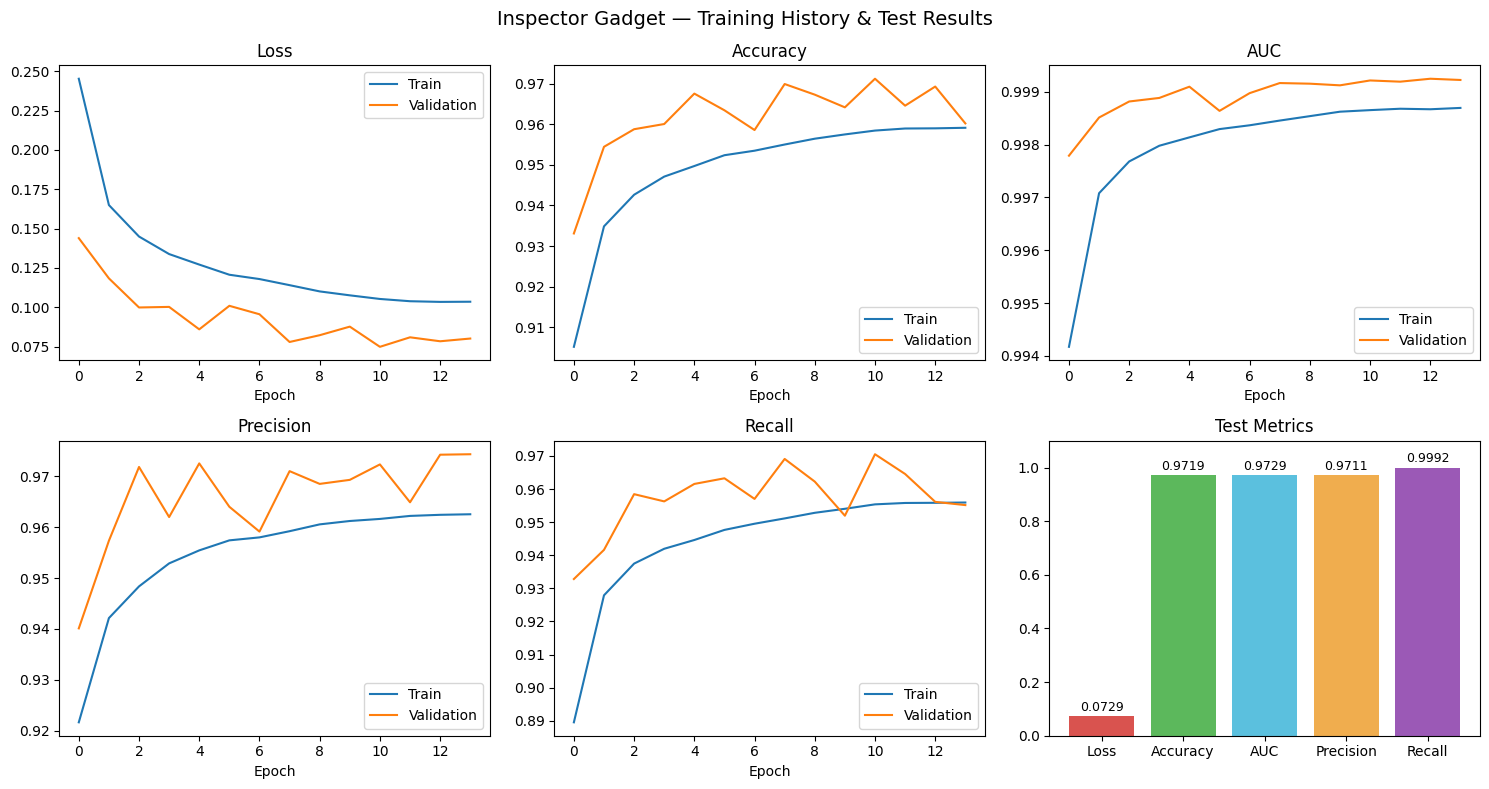

In [14]:
# visualize training
import matplotlib.pyplot as plt

metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
titles  = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].plot(history.history[metric],     label='Train')
    axes[i].plot(history.history[f'val_{metric}'], label='Validation')
    axes[i].set_title(title)
    axes[i].set_xlabel('Epoch')
    axes[i].legend()

# Use last subplot for test metrics
test_labels = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
test_values = [scores[0], scores[1], scores[2], scores[3], scores[4]]
axes[5].bar(test_labels, test_values, color=['#d9534f', '#5cb85c', '#5bc0de', '#f0ad4e', '#9b59b6'])
axes[5].set_title('Test Metrics')
axes[5].set_ylim(0, 1.1)
for j, v in enumerate(test_values):
    axes[5].text(j, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Inspector Gadget — Training History & Test Results', fontsize=14)
plt.tight_layout()
plt.show()


# Saving the model
* We save a keras model to preserve the original model in a Keras zip archive, recommended by the official Keras documentation.
* Because this will be used in an embedded system (Raspberry Pi), we want to also save the model as a TensorFlow Lite model for edge deployment.
* Quantization helps to decrease the overall size of the model by changing the weights from a float32 to 8-bit integers. Calibration data is required to preserve inference accuracy. This calibration data is taken from training data.

In [15]:
# Save the entire model as a `.keras` zip archive.
model.save('Inspector_Gadget.keras')


In [16]:
# Get Calibration Data
y_train_labels = np.argmax(y_train, axis=1) # get integer representation of attack types
Nper_class = 50
indices = [] # track indices of attack types for x_train callibration
for label in np.unique(y_train_labels): # iterate through each attack type
    class_indices = np.where(y_train_labels == label)[0] # get all indices of this attack type
    samples = np.random.choice(class_indices, Nper_class, replace=False) # get 50 random samples from this attack type
    indices.append(samples) # add these indices to index list.
# Flatten indices list to one list
indices = np.concatenate(indices)
# Shuffle indices
np.random.shuffle(indices)
# Use indices to gather equal calibration data from all attack types
calibration_data = X_train[indices]
# Function to specify representative dataset for quantization
def representative_dataset():
    for data in calibration_data:
        yield [data.reshape(1,19)]

# Quantize and convert to TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tflite_quant_model = converter.convert()

# Save the model.
with open('Inspector_Gadget_quant.tflite', 'wb') as f:
  f.write(tflite_quant_model)

INFO:tensorflow:Assets written to: /tmp/tmp87d5sz2k/assets


INFO:tensorflow:Assets written to: /tmp/tmp87d5sz2k/assets


Saved artifact at '/tmp/tmp87d5sz2k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 19), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  131459219419600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219423056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219420368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219422096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219421904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219422288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219834064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219834832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219834448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219835408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131459219835600: Tensor

/home/joshs/miniconda3/envs/CS499_NetworkMonitor/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1774525038.705521    9020 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1774525038.705552    9020 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-03-26 07:37:18.705783: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp87d5sz2k
2026-03-26 07:37:18.706463: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-26 07:37:18.706469: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp87d5sz2k
I0000 00:00:1774525038.712555    9020 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-03-26 07:37:18.713567: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bu

# References:
* Ali, M. L., Thakur, K., Schmeelk, S., Debello, J., & Dragos, D. (2025). Deep learning vs. machine learning for intrusion detection in computer networks: A comparative study. Applied Sciences, 15(4), 1903. https://doi.org/10.3390/app15041903
* Géron, A. (2019). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow (2nd ed.). O'Reilly Media.
* Gulli, A., & Pal, S. (2017). Deep learning with Keras. Packt Publishing. O'Reilly Media.
* Google. (2024). Post-training quantization. Google AI Edge / LiteRT. https://ai.google.dev/edge/litert/conversion/tensorflow/quantization/post_training_quantization
* Google. (2024a). tf.lite.Interpreter. TensorFlow API Documentation. https://www.tensorflow.org/lite/api_docs/python/tf/lite/Interpreter
* Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python toolbox to tackle the curse of imbalanced datasets in machine learning. Journal of Machine Learning Research, 18(17), 1–5. https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
* Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
* Pervez, N. (2023). Intrusion detection using CIC-IDS2017 [GitHub repository]. GitHub. https://github.com/noushinpervez/Intrusion-Detection-CICIDS2017
* Ultralytics. (2026, January 29). What is batch size in machine learning? Ultralytics. https://www.ultralytics.com/glossary/batch-size